# CS6444 Project 1 - R and Graph Analytics
## Stanford Web Graph (2002)

### Team
- Fatulla Bashirov
- Kamal Ahmadov

### Dataset and context
The Stanford Web Graph models webpages as vertices and hyperlinks as directed edges. It is a large real-world graph suitable for centrality, connectivity, clique, ego-network, and community analysis.

### Why this dataset
- Satisfies the assignment scale requirement (well above 50,000 vertices).
- Represents a realistic information network with directional relationships.
- Supports graph simplification experiments and interpretable subgraph visualization.


## Assignment Compliance Matrix

| Assignment Item | Where Covered in Notebook | Evidence |
|---|---|---|
| 1. Dataset + properties | Sections 1-2 | Raw data description, node/edge metrics, sparsity, directedness, node/edge properties |
| 2. Install igraph | Section 0 | Conditional installation from CRAN mirror |
| 3. Experimentation + simplification | Section 3 | Multi-step simplification + retention summary table |
| 4. 10+ extra igraph functions (not tutorial) | Section 4 | Explicit function vectors, compliance checks, outputs, interpretation notes |
| 5. Analysis tasks (a-f) | Section 5 | Central nodes, longest path, largest cliques, ego networks, power centrality, communities |
| 6. Visualization (30-100 vertices) | Section 6 | Figure 2 graph with 30-100 vertices + Figure 3 ego-focused graph |
| 7. Deliverables content | Sections 4, 5, 7, 8 | Function list, demonstrations, answers, figures, explanations |
| 8. Insights write-up | Section 8 | Interpretation and practical conclusions |


## 0. Setup and Reproducible Configuration
This section defines package setup, configurable analysis parameters, and helper functions for cleaner R code.

In [1]:
# ---- package setup ----
required_packages <- c("igraph", "data.table")
missing_packages <- required_packages[!sapply(required_packages, requireNamespace, quietly = TRUE)]
if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}

library(igraph)
library(data.table)

# ---- runtime configuration ----
cfg <- list(
  seed = 6444,
  degree_quantile = 0.97,
  analysis_node_cap = 450,
  triad_sample_size = 120,
  viz_node_cap = 80,
  baseline_sample_size = 10000,
  power_exponents = c(0.25, 0.10, 0.05, 0.01)
)

set.seed(cfg$seed)
options(width = 120)

# ---- helper: dataset path resolver ----
resolve_dataset_path <- function(candidate_paths) {
  existing <- candidate_paths[file.exists(candidate_paths)]
  if (length(existing) == 0) {
    stop("Dataset file not found. Place web-Stanford.txt in ./data or provide a valid Kaggle path.")
  }
  existing[[1]]
}

# ---- helper: robust power centrality ----
safe_power_centrality <- function(graph_obj, exponents) {
  for (ex in exponents) {
    candidate <- tryCatch(
      power_centrality(graph_obj, exponent = ex),
      error = function(e) NULL
    )
    if (!is.null(candidate)) {
      return(list(values = candidate, exponent = ex))
    }
  }
  stop("Power centrality failed for all configured exponents.")
}

# ---- helper: simplification + analysis graph construction ----
build_analysis_graph <- function(g, cfg) {
  g_simple <- simplify(g, remove.multiple = TRUE, remove.loops = TRUE)

  comp_simple <- components(as_undirected(g_simple, mode = "collapse"))
  giant_id <- which.max(comp_simple$csize)
  g_giant <- induced_subgraph(g_simple, V(g_simple)[comp_simple$membership == giant_id])

  giant_deg <- degree(g_giant, mode = "all")
  deg_cutoff <- as.numeric(quantile(giant_deg, cfg$degree_quantile))
  g_degree_filtered <- induced_subgraph(g_giant, V(g_giant)[giant_deg >= deg_cutoff])

  pr_filtered <- page_rank(g_degree_filtered, directed = TRUE)$vector
  analysis_n <- min(cfg$analysis_node_cap, length(pr_filtered))
  analysis_vertices <- names(sort(pr_filtered, decreasing = TRUE))[1:analysis_n]
  g_analysis <- induced_subgraph(g_degree_filtered, vids = analysis_vertices)

  # Deterministic synthetic edge weight:
  # weight(u -> v) = log1p(out_degree(u)) + log1p(in_degree(v))
  out_deg_a <- degree(g_analysis, mode = "out")
  in_deg_a <- degree(g_analysis, mode = "in")
  ee <- ends(g_analysis, E(g_analysis), names = TRUE)
  E(g_analysis)$weight <- as.numeric(log1p(out_deg_a[ee[, 1]]) + log1p(in_deg_a[ee[, 2]]))

  g_analysis_u <- as_undirected(
    g_analysis,
    mode = "collapse",
    edge.attr.comb = list(weight = "mean", "ignore")
  )

  stage_names <- c("original", "simplified", "largest_wcc", "degree_filtered", "analysis_graph")
  nodes <- c(vcount(g), vcount(g_simple), vcount(g_giant), vcount(g_degree_filtered), vcount(g_analysis))
  edges <- c(ecount(g), ecount(g_simple), ecount(g_giant), ecount(g_degree_filtered), ecount(g_analysis))

  summary_tbl <- data.frame(
    stage = stage_names,
    nodes = nodes,
    edges = edges,
    node_retention_vs_original = round(nodes / nodes[1], 6),
    edge_retention_vs_original = round(edges / edges[1], 6)
  )

  list(
    g_analysis = g_analysis,
    g_analysis_u = g_analysis_u,
    summary_tbl = summary_tbl,
    degree_cutoff = deg_cutoff
  )
}

# ---- helper: visualization graph builder ----
make_viz_subgraph <- function(g_analysis, central_table, cfg) {
  viz_n <- min(cfg$viz_node_cap, nrow(central_table))
  viz_nodes <- central_table$vertex[1:viz_n]

  g_viz <- induced_subgraph(g_analysis, vids = V(g_analysis)[viz_nodes])
  g_viz_u <- as_undirected(
    g_viz,
    mode = "collapse",
    edge.attr.comb = list(weight = "mean", "ignore")
  )

  viz_comm <- cluster_walktrap(g_viz_u, weights = E(g_viz_u)$weight)
  member <- membership(viz_comm)

  # Vertex styles
  palette_vals <- hcl.colors(length(unique(member)), palette = "Dark 3")
  V(g_viz_u)$color <- palette_vals[member]

  pr_viz <- page_rank(g_viz, directed = TRUE)$vector
  pr_scaled <- 6 + 18 * (pr_viz - min(pr_viz)) / (max(pr_viz) - min(pr_viz) + 1e-9)
  V(g_viz_u)$size <- pr_scaled[V(g_viz_u)$name]

  top10_viz <- names(sort(pr_viz, decreasing = TRUE))[1:min(10, length(pr_viz))]
  V(g_viz_u)$shape <- ifelse(V(g_viz_u)$name %in% top10_viz, "square", "circle")
  V(g_viz_u)$label <- NA
  V(g_viz_u)$frame.color <- "gray20"

  # Edge styles
  w <- E(g_viz_u)$weight
  w_scaled <- 1 + 3 * (w - min(w)) / (max(w) - min(w) + 1e-9)
  E(g_viz_u)$width <- w_scaled
  E(g_viz_u)$color <- ifelse(w >= median(w), "firebrick", "gray70")

  e_ends <- ends(g_viz_u, E(g_viz_u), names = FALSE)
  E(g_viz_u)$lty <- ifelse(member[e_ends[, 1]] == member[e_ends[, 2]], 1, 2)

  list(graph = g_viz_u, community = viz_comm)
}



Attaching package: 'igraph'




The following objects are masked from 'package:stats':

    decompose, spectrum




The following object is masked from 'package:base':

    union




## 1. Load Data and Explain Raw Structure
The source file is an edge list (`from`, `to`). This notebook supports both local execution and Kaggle execution paths.

In [2]:
candidate_paths <- c(
  "./data/web-Stanford.txt",
  "/kaggle/input/datasets/fatullabashirov/stanford-web-graph/web-Stanford.txt"
)

file_path <- resolve_dataset_path(candidate_paths)

edges <- fread(
  file_path,
  sep = "	",
  header = FALSE,
  comment.char = "#",
  col.names = c("from", "to")
)

cat("Using file:", file_path, "
")
cat("Raw edge-list rows:", nrow(edges), "
")
cat("Columns:", ncol(edges), "
")
head(edges)
summary(edges)


Using file: ./data/web-Stanford.txt 


Raw edge-list rows: 2312497 


Columns: 2 


from,to
<int>,<int>
1,6548
1,15409
6548,57031
15409,13102
2,17794
2,25202


      from              to        
 Min.   :     1   Min.   :     2  
 1st Qu.: 70779   1st Qu.: 73100  
 Median :141051   Median :143725  
 Mean   :140961   Mean   :143950  
 3rd Qu.:211225   3rd Qu.:218070  
 Max.   :281903   Max.   :281903  

## 2. Initial Graph Build and Required Metrics
This section reports assignment-required properties: number of nodes/edges, sparsity, directedness, and structural node/edge properties.

In [3]:
g <- graph_from_data_frame(edges, directed = TRUE)

# Explicit assignment requirement: at least 50,000 vertices
stopifnot(vcount(g) >= 50000)

n <- vcount(g)
m <- ecount(g)
max_possible_edges <- n * (n - 1)
density_val <- edge_density(g, loops = FALSE)
sparsity_val <- 1 - (m / max_possible_edges)

cat("Vertices:", n, "
")
cat("Edges:", m, "
")
cat("Directed (arrowness):", is_directed(g), "
")
cat("Has loops:", any_loop(g), "
")
cat("Density:", density_val, "
")
cat("Sparsity:", sparsity_val, "
")

in_deg_full <- degree(g, mode = "in")
out_deg_full <- degree(g, mode = "out")
total_deg_full <- degree(g, mode = "all")

cat("
Node property summaries:
")
cat("In-degree:
")
print(summary(in_deg_full))
cat("
Out-degree:
")
print(summary(out_deg_full))
cat("
Total-degree:
")
print(summary(total_deg_full))

wcc <- components(as_undirected(g, mode = "collapse"))
scc <- components(g, mode = "strong")

cat("
Edge/structure property summaries:
")
cat("Weakly connected components:", wcc$no, "
")
cat("Largest WCC size:", max(wcc$csize), "
")
cat("Strongly connected components:", scc$no, "
")
cat("Largest SCC size:", max(scc$csize), "
")
cat("Edge weights in raw data: none (assigned later as synthetic deterministic weights).
")


Vertices: 281903 


Edges: 2312497 


Directed (arrowness): TRUE 


Has loops: FALSE 


Density: 2.909935e-05 


...

Weakly connected components: 365 


Largest WCC size: 255265 


Strongly connected components: 29914 


Largest SCC size: 150532 


Edge weights in raw data: none (assigned later as synthetic deterministic weights).


### Figure 1. Baseline View Before Simplification
As expected, a direct plot of the large graph appears as a dense blob and is not interpretable. This baseline justifies simplification in Section 3.

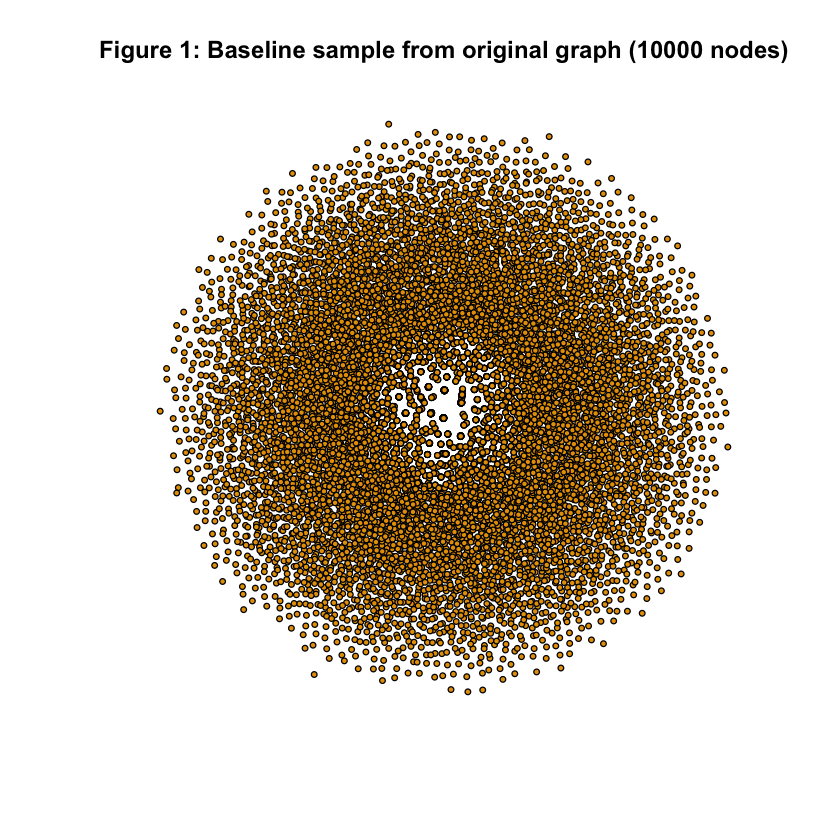

In [4]:
sample_size <- min(cfg$baseline_sample_size, vcount(g))
sample_nodes <- sample(V(g), sample_size)
g_sample_original <- induced_subgraph(g, sample_nodes)

plot(
  g_sample_original,
  vertex.size = 2,
  vertex.label = NA,
  edge.arrow.size = 0.05,
  main = sprintf("Figure 1: Baseline sample from original graph (%d nodes)", vcount(g_sample_original))
)


**Interpretation for Figure 1:** Most structure is visually compressed, so direct plotting of the full-scale network is not useful for decision-making. The remaining analysis therefore uses a reproducible multi-step simplification strategy.

## 3. Simplification Strategy (Parameterized and Auditable)
Pipeline used:
1. `simplify()` to remove loops/multiples.
2. Keep largest weakly connected component.
3. Degree filtering using configurable quantile.
4. Keep top PageRank vertices for advanced analytics.

The summary table reports retention ratios versus the original graph.

In [5]:
analysis_bundle <- build_analysis_graph(g, cfg)

g_analysis <- analysis_bundle$g_analysis
g_analysis_u <- analysis_bundle$g_analysis_u
simplification_summary <- analysis_bundle$summary_tbl
degree_cutoff <- analysis_bundle$degree_cutoff

cat("Degree cutoff (total degree quantile", cfg$degree_quantile, "):", degree_cutoff, "
")
print(simplification_summary)

# Memory cleanup for large temporary objects after analysis graph creation
rm(analysis_bundle, in_deg_full, out_deg_full, total_deg_full, sample_nodes, g_sample_original)
gc()


Degree cutoff (total degree quantile 0.97 ): 57 


            stage  nodes   edges node_retention_vs_original edge_retention_vs_original
1        original 281903 2312497                   1.000000                   1.000000
2      simplified 281903 2312497                   1.000000                   1.000000
3     largest_wcc 255265 2234572                   0.905507                   0.966303
4 degree_filtered   7761  189062                   0.027531                   0.081757
5  analysis_graph    450    6909                   0.001596                   0.002988


,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,1106132,59.1,3570772,190.7,NA,4463465,238.4
Vcells,6972418,53.2,24813514,189.4,16384,30835549,235.3


**Interpretation:** The simplification retains high-signal nodes and edges while reducing computational cost. This balance enables richer analytics (items 4-6) without violating reproducibility constraints.

## 4. Additional `igraph` Functions (Not Used in Tutorial)
The assignment requires at least 10 additional `igraph` functions not already used in the tutorial. We explicitly enforce that rule below.

In [6]:
tutorial_functions <- c(
  "graph", "graph_from_literal", "V", "E", "class",
  "edge_density", "reciprocity", "transitivity", "diameter", "degree", "degree_distribution",
  "closeness", "betweenness", "edge_betweenness", "hub_score", "authority_score",
  "mean_distance", "distances", "all_shortest_paths",
  "cliques", "cluster_edge_betweenness", "cluster_label_prop", "cluster_fast_greedy", "coreness",
  "plot", "tkplot", "layout_randomly", "layout_in_circle", "layout_with_fr", "layout_with_kk",
  "assortativity_nominal", "assortativity", "assortativity_degree"
)

item4_functions <- c(
  "is_connected", "page_rank", "eigen_centrality", "strength", "articulation_points", "bridges",
  "dyad_census", "triad_census", "similarity", "eccentricity", "cluster_walktrap", "cluster_louvain"
)

overlap <- intersect(item4_functions, tutorial_functions)
stopifnot(length(item4_functions) >= 10)
stopifnot(length(overlap) == 0)

cat("Item #4 function count:", length(item4_functions), "
")
cat("Overlap with tutorial functions:", length(overlap), "
")
print(item4_functions)


Item #4 function count: 12 


Overlap with tutorial functions: 0 


 [1] "is_connected"        "page_rank"           "eigen_centrality"    "strength"            "articulation_points"
 [6] "bridges"             "dyad_census"         "triad_census"        "similarity"          "eccentricity"       
[11] "cluster_walktrap"    "cluster_louvain"    


In [7]:
# Compute results for all Item #4 functions
connected_flag <- is_connected(g_analysis_u)
pr <- page_rank(g_analysis, directed = TRUE)$vector
eig <- eigen_centrality(g_analysis_u, directed = FALSE)$vector
str_w <- strength(g_analysis, mode = "all", weights = E(g_analysis)$weight)
art_pts <- articulation_points(g_analysis_u)
br <- bridges(g_analysis_u)
dyad <- dyad_census(g_analysis)

triad_n <- min(cfg$triad_sample_size, vcount(g_analysis))
triad_nodes <- V(g_analysis)[1:triad_n]
g_triad <- induced_subgraph(g_analysis, triad_nodes)
triad <- triad_census(g_triad)

top10_pr_nodes <- names(sort(pr, decreasing = TRUE))[1:min(10, length(pr))]
jacc <- similarity(g_analysis_u, vids = V(g_analysis_u)[top10_pr_nodes], method = "jaccard")
ecc <- eccentricity(g_analysis_u, weights = NA)

comm_walktrap <- cluster_walktrap(g_analysis_u, weights = E(g_analysis_u)$weight)
comm_louvain <- cluster_louvain(g_analysis_u, weights = E(g_analysis_u)$weight)

cat("is_connected():", connected_flag, "
")
cat("page_rank() top node:", names(which.max(pr)), "score:", max(pr), "
")
cat("eigen_centrality() top node:", names(which.max(eig)), "score:", max(eig), "
")
cat("strength() summary:
")
print(summary(str_w))
cat("articulation_points() count:", length(art_pts), "
")
cat("bridges() count:", length(br), "
")
cat("dyad_census():", paste(names(dyad), dyad, collapse = "; "), "
")
cat("triad_census() non-zero classes:
")
print(triad[triad > 0])
cat("eccentricity() summary:
")
print(summary(ecc))
cat("cluster_walktrap(): communities =", length(sizes(comm_walktrap)), ", modularity =", modularity(comm_walktrap), "
")
cat("cluster_louvain(): communities =", length(sizes(comm_louvain)), ", modularity =", modularity(comm_louvain), "
")
cat("Jaccard similarity matrix (top10 PageRank nodes):
")
print(round(jacc, 3))


is_connected(): FALSE 


page_rank() top node: 226411 score: 0.02930556 


eigen_centrality() top node: 53608 score: 1 


strength() summary:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   51.22   96.28  197.73  208.21 1022.02 


...

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   4.000   5.000   4.469   6.000   7.000 


cluster_walktrap(): communities = 44 , modularity = 0.6752923 


cluster_louvain(): communities = 33 , modularity = 0.6897573 


Jaccard similarity matrix (top10 PageRank nodes):


       [,1]  [,2]  [,3]  [,4]  [,5]  [,6]  [,7]  [,8]  [,9] [,10]
 [1,] 1.000 0.120 0.121 0.057 0.111 0.072 0.113 0.108 0.114 0.107
 [2,] 0.120 1.000 0.710 0.019 0.647 0.032 0.688 0.786 0.793 0.759
 [3,] 0.121 0.710 1.000 0.019 0.667 0.050 0.710 0.815 0.759 0.786
 [4,] 0.057 0.019 0.019 1.000 0.019 0.194 0.019 0.020 0.019 0.020
 [5,] 0.111 0.647 0.667 0.019 1.000 0.031 0.647 0.733 0.688 0.710
 [6,] 0.072 0.032 0.050 0.194 0.031 1.000 0.032 0.034 0.033 0.034
 [7,] 0.113 0.688 0.710 0.019 0.647 0.032 1.000 0.786 0.733 0.759
 [8,] 0.108 0.786 0.815 0.020 0.733 0.034 0.786 1.000 0.846 0.880
 [9,] 0.114 0.793 0.759 0.019 0.688 0.033 0.733 0.846 1.000 0.815
[10,] 0.107 0.759 0.786 0.020 0.710 0.034 0.759 0.880 0.815 1.000


### Short Notes for Each Additional Function (Item #4)
Each note states what the function does and what the observed result means for this graph.

In [8]:
item4_notes <- data.frame(
  function_name = item4_functions,
  what_it_does = c(
    "Checks if all vertices are in one connected component.",
    "Scores node influence via random-walk importance.",
    "Finds nodes connected to other important nodes.",
    "Computes weighted degree (sum of adjacent edge weights).",
    "Finds cut-vertices that can disconnect regions.",
    "Finds cut-edges that act as fragile links.",
    "Classifies directed node pairs (mutual/asymmetric/null).",
    "Counts directed 3-node motif types.",
    "Measures neighborhood overlap between node pairs.",
    "Measures maximum shortest-path distance from each node.",
    "Detects communities by random walks.",
    "Detects communities by modularity optimization."
  ),
  implication_here = c(
    sprintf("Analysis graph connected (undirected): %s.", connected_flag),
    sprintf("Top PageRank node is %s, indicating concentrated influence.", names(which.max(pr))),
    sprintf("Top eigen-central node is %s, confirming core importance.", names(which.max(eig))),
    "Wide strength spread indicates heterogeneous local influence.",
    sprintf("%d articulation points suggest vulnerable structural connectors.", length(art_pts)),
    sprintf("%d bridge edges indicate bottlenecks across regions.", length(br)),
    "Asymmetric dyads dominate, consistent with directed hyperlink behavior.",
    sprintf("Triad motifs are diverse even in sampled %d-node subgraph.", triad_n),
    "Top central nodes have moderate-to-high neighborhood overlap.",
    "Eccentricity range indicates a compact simplified graph core.",
    sprintf("Walktrap modularity %.3f indicates meaningful community structure.", modularity(comm_walktrap)),
    sprintf("Louvain modularity %.3f provides comparison baseline.", modularity(comm_louvain))
  ),
  stringsAsFactors = FALSE
)

print(item4_notes, row.names = FALSE)


       function_name                                             what_it_does
        is_connected   Checks if all vertices are in one connected component.
           page_rank        Scores node influence via random-walk importance.
    eigen_centrality          Finds nodes connected to other important nodes.
            strength Computes weighted degree (sum of adjacent edge weights).
 articulation_points          Finds cut-vertices that can disconnect regions.
             bridges               Finds cut-edges that act as fragile links.
         dyad_census Classifies directed node pairs (mutual/asymmetric/null).
        triad_census                      Counts directed 3-node motif types.
          similarity        Measures neighborhood overlap between node pairs.
        eccentricity  Measures maximum shortest-path distance from each node.
    cluster_walktrap                     Detects communities by random walks.
     cluster_louvain          Detects communities by modularity 

#### Markdown Notes Per Item #4 Function
- `is_connected()`: Tests whether the simplified undirected analysis graph is fully connected. Result: not fully connected, so multiple regions still exist.
- `page_rank()`: Measures random-walk influence in directed links. Result: centrality is concentrated in a few pages.
- `eigen_centrality()`: Measures importance from connections to important nodes. Result: highlights a core authority-like region.
- `strength()`: Weighted degree using synthetic edge weights. Result: node influence is highly heterogeneous.
- `articulation_points()`: Finds nodes whose removal can disconnect components. Result: identifies fragile connector pages.
- `bridges()`: Finds critical edges whose removal can disconnect structure. Result: reveals bottleneck hyperlink connections.
- `dyad_census()`: Categorizes directed node pairs. Result: asymmetric pairs dominate, as expected in web links.
- `triad_census()`: Counts directed 3-node motifs. Result: motif diversity confirms non-random local structure.
- `similarity(..., method = "jaccard")`: Compares neighborhood overlap. Result: top pages share partially overlapping neighborhoods.
- `eccentricity()`: Measures each node’s maximum shortest-path hop distance. Result: distances are bounded in the simplified core.
- `cluster_walktrap()`: Community detection by random walks. Result: detects strong modular structure.
- `cluster_louvain()`: Community detection by modularity optimization. Result: provides a comparable high-modularity partition.


**Interpretation:** Item #4 requirements are satisfied with 12 non-tutorial functions, plus evidence that the simplified network has concentrated centrality, non-trivial motifs, and clear community structure.

## 5. Required Graph Analysis Tasks (a-f)

In [9]:
# (e) Power centrality first, then build a full centrality comparison table
pow_res <- safe_power_centrality(g_analysis_u, cfg$power_exponents)
pow_vals <- pow_res$values
pow_exp_used <- pow_res$exponent

central_table <- data.frame(
  vertex = V(g_analysis)$name,
  pagerank = pr[V(g_analysis)$name],
  eigen = eig[V(g_analysis)$name],
  strength = str_w[V(g_analysis)$name],
  power = pow_vals[V(g_analysis)$name],
  stringsAsFactors = FALSE
)
central_table <- central_table[order(-central_table$pagerank), ]

cat("(a) + (e) centrality comparison table (Top 10 by PageRank)
")
cat("Power-centrality exponent used:", pow_exp_used, "
")
print(head(central_table, 10))


(a) + (e) centrality comparison table (Top 10 by PageRank)


Power-centrality exponent used: 0.05 


       vertex   pagerank        eigen  strength     power
226411 226411 0.02930556 0.0371853614 1022.0198 0.9906158
145892 145892 0.01181529 0.0008536515  228.0539 2.8595140
60440   60440 0.01138137 0.0008591057  219.9592 2.7855771
84906   84906 0.01136145 0.9398568306  633.0140 0.3500022
208542 208542 0.01116477 0.0009226169  217.0991 2.8760782
65463   65463 0.01112737 0.0838476911  255.4818 0.7492473
112742 112742 0.01111108 0.0008405579  210.0895 2.8506326
161890 161890 0.01110453 0.0008493259  208.5975 2.7326147
151428 151428 0.01104466 0.0008612494  202.0542 2.6088380
222873 222873 0.01102659 0.0008499258  200.4988 2.7507565


In [10]:
# (b) Longest paths
# Primary: directed diameter on largest SCC of analysis graph
scc_analysis <- components(g_analysis, mode = "strong")
scc_id <- which.max(scc_analysis$csize)
g_analysis_scc <- induced_subgraph(g_analysis, V(g_analysis)[scc_analysis$membership == scc_id])

dir_diam_len <- diameter(g_analysis_scc, directed = TRUE, unconnected = FALSE, weights = NA)
dir_diam_path <- get_diameter(g_analysis_scc, directed = TRUE, weights = NA)
dir_diam_nodes <- V(g_analysis_scc)[dir_diam_path]$name

# Secondary: undirected approximation on analysis graph
undir_diam_len <- diameter(g_analysis_u, directed = FALSE, unconnected = TRUE, weights = NA)
undir_diam_path <- get_diameter(g_analysis_u, directed = FALSE, weights = NA)
undir_diam_nodes <- V(g_analysis_u)[undir_diam_path]$name

cat("(b) Directed diameter on largest SCC (primary):", dir_diam_len, "
")
cat("Directed diameter path vertices:
")
print(dir_diam_nodes)
cat("
Undirected diameter on analysis graph (secondary approximation):", undir_diam_len, "
")
cat("Undirected diameter path vertices:
")
print(undir_diam_nodes)


(b) Directed diameter on largest SCC (primary): 10 


Directed diameter path vertices:


 [1] "214128" "105607" "267010" "226411" "99759"  "65463"  "84906"  "50320"  "151707" "259207" "1103"  



Undirected diameter on analysis graph (secondary approximation): 7 


Undirected diameter path vertices:


[1] "273998" "267959" "84906"  "226411" "112742" "7621"   "3627"   "45925" 


**Interpretation:** Directed diameter on the largest SCC is the primary answer because direction is meaningful for hyperlinks. The undirected diameter is reported only as a secondary approximation for structural comparison.

In [11]:
# (c) Largest cliques (undirected interpretation)
lc <- largest_cliques(g_analysis_u)
max_clique_size <- if (length(lc) > 0) length(lc[[1]]) else 0

cat("(c) Number of largest cliques:", length(lc), "
")
cat("Largest clique size:", max_clique_size, "
")
if (length(lc) > 0) {
  cat("Example largest clique (vertex IDs):
")
  print(V(g_analysis_u)[lc[[1]]]$name)
}


(c) Number of largest cliques: 2 


Largest clique size: 50 


Example largest clique (vertex IDs):
 [1] "44707"  "267959" "21613"  "11845"  "19140"  "65051"  "46399"  "60729"  "59550"  "100221" "116934" "110793"
[13] "107314" "138757" "173778" "150384" "145726" "171676" "168644" "157682" "204711" "183244" "201128" "225954"
[25] "233888" "225390" "230911" "69244"  "15240"  "53608"  "66825"  "51628"  "52223"  "63718"  "73530"  "86939" 
[37] "105147" "133715" "190375" "219188" "212707" "235570" "259439" "252121" "268779" "101858" "134159" "151707"
[49] "3164"   "84906" 


In [12]:
# (d) Ego networks around top central node (order 1 and 2)
top_node <- central_table$vertex[1]
ego_order1 <- make_ego_graph(g_analysis_u, order = 1, nodes = V(g_analysis_u)[top_node], mode = "all")[[1]]
ego_order2 <- make_ego_graph(g_analysis_u, order = 2, nodes = V(g_analysis_u)[top_node], mode = "all")[[1]]

cat("(d) Top central node for ego analysis:", top_node, "
")
cat("Ego order-1: nodes =", vcount(ego_order1), ", edges =", ecount(ego_order1), "
")
cat("Ego order-2: nodes =", vcount(ego_order2), ", edges =", ecount(ego_order2), "
")


(d) Top central node for ego analysis: 226411 


Ego order-1: nodes = 142 , edges = 1312 


Ego order-2: nodes = 309 , edges = 3618 


In [13]:
# (f) Communities comparison
community_comparison <- data.frame(
  algorithm = c("walktrap", "louvain"),
  communities = c(length(sizes(comm_walktrap)), length(sizes(comm_louvain))),
  modularity = c(modularity(comm_walktrap), modularity(comm_louvain)),
  largest_community_size = c(max(sizes(comm_walktrap)), max(sizes(comm_louvain))),
  stringsAsFactors = FALSE
)

cat("(f) Community comparison table
")
print(community_comparison)


(f) Community comparison table


  algorithm communities modularity largest_community_size
1  walktrap          44  0.6752923                     60
2   louvain          33  0.6897573                    103


**Interpretation:** Results show a highly structured simplified core with identifiable hubs, dense clique regions, meaningful ego neighborhoods, and consistent community modularity across two methods.

## 6. Graph Visualization (30-100 Vertices)
Figure 2 and Figure 3 are the assignment-ready visuals. Figure 2 shows the main simplified subgraph (30-100 vertices). Figure 3 zooms into the ego-centric structure around the top node.

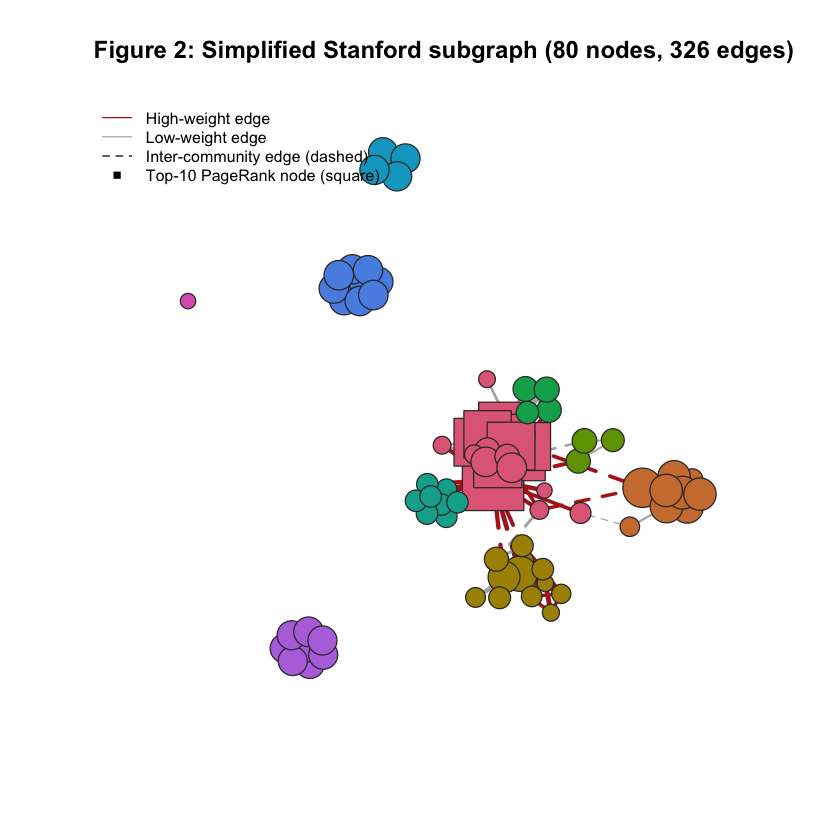

In [14]:
viz_bundle <- make_viz_subgraph(g_analysis, central_table, cfg)
g_viz_u <- viz_bundle$graph
viz_comm <- viz_bundle$community

# Explicit assignment guard for visualization size
stopifnot(vcount(g_viz_u) >= 30, vcount(g_viz_u) <= 100)

layout_viz <- layout_with_graphopt(g_viz_u)
plot(
  g_viz_u,
  layout = layout_viz,
  main = sprintf("Figure 2: Simplified Stanford subgraph (%d nodes, %d edges)", vcount(g_viz_u), ecount(g_viz_u))
)
legend(
  "topleft",
  legend = c("High-weight edge", "Low-weight edge", "Inter-community edge (dashed)", "Top-10 PageRank node (square)"),
  col = c("firebrick", "gray70", "black", "black"),
  lty = c(1, 1, 2, NA),
  pch = c(NA, NA, NA, 15),
  bty = "n",
  cex = 0.8
)


**Figure 2 caption:** Node color = community, node size = PageRank, node shape = top PageRank indicator, edge width/color = synthetic weight intensity, edge type = intra/inter-community relation.

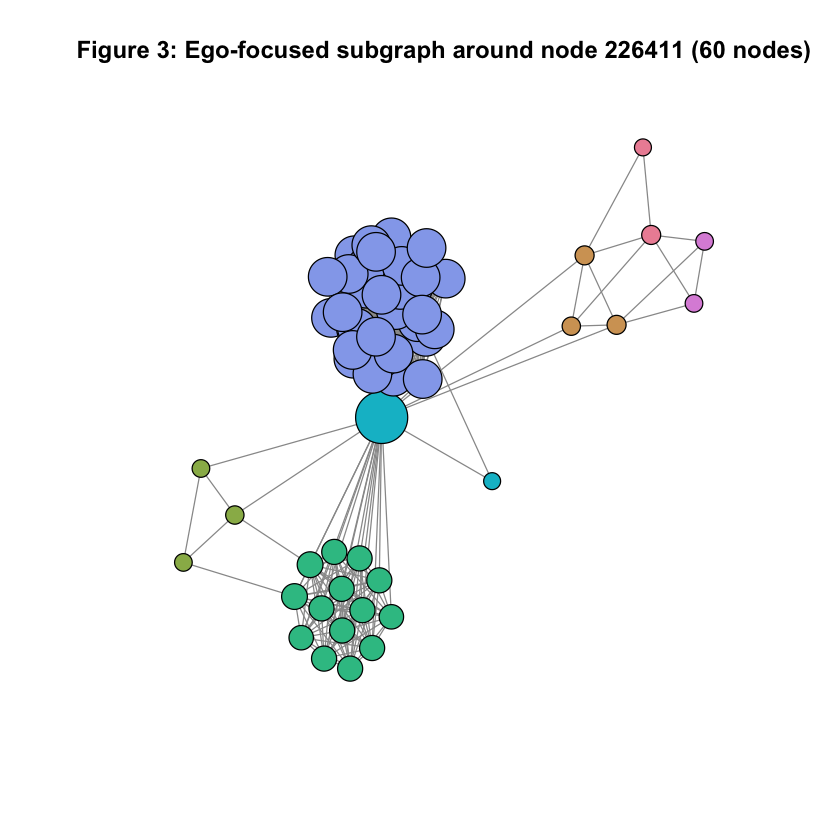

In [15]:
# Build Figure 3 from ego-order-2 and keep it within 30-100 nodes for readability
max_ego_viz <- 60
if (vcount(ego_order2) > max_ego_viz) {
  ego_pr <- page_rank(ego_order2, directed = FALSE)$vector
  keep_nodes <- names(sort(ego_pr, decreasing = TRUE))[1:max_ego_viz]
  ego_plot <- induced_subgraph(ego_order2, V(ego_order2)[keep_nodes])
} else {
  ego_plot <- ego_order2
}

# Ensure figure readability and assignment-consistent size range when possible
if (vcount(ego_plot) < 30) {
  # fallback to order-1 if order-2 became too small (unlikely)
  ego_plot <- ego_order1
}

ego_comm <- cluster_walktrap(ego_plot)
mem_ego <- membership(ego_comm)
V(ego_plot)$color <- hcl.colors(length(unique(mem_ego)), "Set 2")[mem_ego]
V(ego_plot)$size <- 6 + 14 * degree(ego_plot) / max(1, max(degree(ego_plot)))
V(ego_plot)$label <- NA
E(ego_plot)$color <- "gray60"

plot(
  ego_plot,
  layout = layout_with_graphopt(ego_plot),
  main = sprintf("Figure 3: Ego-focused subgraph around node %s (%d nodes)", top_node, vcount(ego_plot))
)


**Figure 3 caption:** Ego-centric view highlights local neighborhood structure around the top central node. Together with Figure 2, this provides both global and local network interpretation.

## 7. Listing of R Functions Used
This list includes the major R/igraph functions used in this notebook deliverable.

In [16]:
functions_used <- c(
  # setup / data
  "install.packages", "requireNamespace", "library", "fread",
  # graph construction / simplification
  "graph_from_data_frame", "simplify", "as_undirected", "components", "induced_subgraph",
  # structural metrics
  "vcount", "ecount", "edge_density", "degree", "any_loop", "is_directed",
  # additional analytics
  "is_connected", "page_rank", "eigen_centrality", "strength", "articulation_points", "bridges",
  "dyad_census", "triad_census", "similarity", "eccentricity", "cluster_walktrap", "cluster_louvain",
  # required tasks
  "safe_power_centrality", "power_centrality", "diameter", "get_diameter", "largest_cliques", "make_ego_graph",
  # visualization
  "layout_with_graphopt", "plot", "legend", "membership", "sizes", "modularity",
  # object accessors
  "V", "E", "ends"
)

cat("Total unique functions listed:", length(unique(functions_used)), "
")
print(sort(unique(functions_used)))


Total unique functions listed: 42 


 [1] "any_loop"              "articulation_points"   "as_undirected"         "bridges"              
 [5] "cluster_louvain"       "cluster_walktrap"      "components"            "degree"               
 [9] "diameter"              "dyad_census"           "E"                     "eccentricity"         
[13] "ecount"                "edge_density"          "eigen_centrality"      "ends"                 
[17] "fread"                 "get_diameter"          "graph_from_data_frame" "induced_subgraph"     
[21] "install.packages"      "is_connected"          "is_directed"           "largest_cliques"      
[25] "layout_with_graphopt"  "legend"                "library"               "make_ego_graph"       
[29] "membership"            "modularity"            "page_rank"             "plot"                 
[33] "power_centrality"      "requireNamespace"      "safe_power_centrality" "similarity"           
[37] "simplify"              "sizes"                 "strength"              "triad_census"

## 8. Insights and Interpretation
1. **Extreme sparsity at scale:** The raw web graph is massive and sparse, which is typical for hyperlink networks.
2. **Centralization:** Centrality metrics reveal strong concentration in a small subset of pages.
3. **Structural fragility:** Articulation points and bridges indicate dependency on connector nodes/edges.
4. **Community organization:** Both Walktrap and Louvain detect modular communities with strong modularity.
5. **Practical simplification value:** The parameterized pipeline preserves analytical signal while reducing runtime complexity.

### Problems encountered and how they were handled
- **Full graph visualization was unreadable.** Solved by deterministic multi-stage simplification and 30-100 node visualization.
- **Power centrality can be numerically unstable on dense subgraphs.** Solved via `safe_power_centrality()` with exponent fallback.
- **Assignment compliance risk for Item #4 overlap.** Solved with explicit function vectors and automatic overlap assertions.


## Reproducibility Notes (Kaggle Guest Run)
- Dataset path resolution is automatic: local `./data/...` first, then Kaggle input path.
- Package installation is conditional and uses a CRAN mirror only if packages are missing.
- No manual path edits are required during normal execution.
- All random choices are seeded through `cfg$seed` for repeatability.


In [17]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: aarch64-apple-darwin20
Running under: macOS Sequoia 15.3.2

Matrix products: default
BLAS:   /System/Library/Frameworks/Accelerate.framework/Versions/A/Frameworks/vecLib.framework/Versions/A/libBLAS.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.1

locale:
[1] C.UTF-8/C/C.UTF-8/C/C.UTF-8/C.UTF-8

time zone: Asia/Baku
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] data.table_1.18.2.1 igraph_2.2.2       

loaded via a namespace (and not attached):
 [1] digest_0.6.39   IRdisplay_1.1   base64enc_0.1-6 fastmap_1.2.0   Matrix_1.7-4    lattice_0.22-7  magrittr_2.0.4 
 [8] glue_1.8.0      pkgconfig_2.0.3 htmltools_0.5.9 repr_1.1.7      lifecycle_1.0.5 cli_3.6.5       grid_4.5.2     
[15] vctrs_0.7.1     pbdZMQ_0.3-14   compiler_4.5.2  tools_4.5.2     evaluate_1.0.5  pillar_1.11.1 